<h1 style="text-align: center;">Individual Assignment 1 - Part 1</h1>
<h3 style="text-align: center;">Case Studies for Data Science - semester 2 2026</h3> 
<h4 style="text-align: center;"> Rose Munro s4054011 </h4>


In [89]:
import pandas as pd
from pathlib import Path 
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet #as we have a few metric from each category (income, education etc) predictors are highly correlated
from sklearn.preprocessing import StandardScaler #Elastic net sensitive to scale

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold


---

### 1. Data Loading


#### Load AEDC Data (Target)

In [90]:
aedc_target = pd.read_excel("data\\aedc_target.xlsx",
              sheet_name = "Target_sorted",
              dtype={"Code": str},
              na_values="*")
aedc_target.head()

,Code,Name,#Valid_Scores,#Dev_Vulnerable,%Dev_Vulnerable
0,101021007,Braidwood,48,2.0,4.166667
1,101021008,Karabar,98,17.0,17.346939
2,101021009,Queanbeyan,125,17.0,13.600000
3,101021010,Queanbeyan - East,62,7.0,11.290323
4,101021012,Queanbeyan West - Jerrabomberra,195,15.0,7.692308


In [91]:
aedc_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Code             2210 non-null   str    
 1   Name             2210 non-null   str    
 2   #Valid_Scores    2210 non-null   int64  
 3   #Dev_Vulnerable  2138 non-null   float64
 4   %Dev_Vulnerable  2138 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 86.5 KB


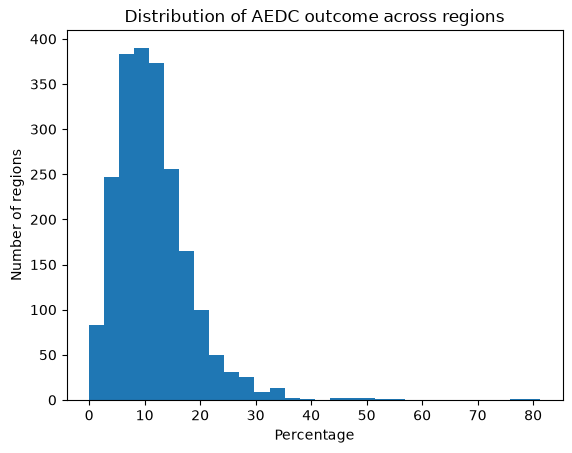

In [92]:
aedc_target["%Dev_Vulnerable"].plot.hist(bins=30)
plt.xlabel("Percentage")
plt.ylabel("Number of regions")
plt.title("Distribution of AEDC outcome across regions")
plt.show()

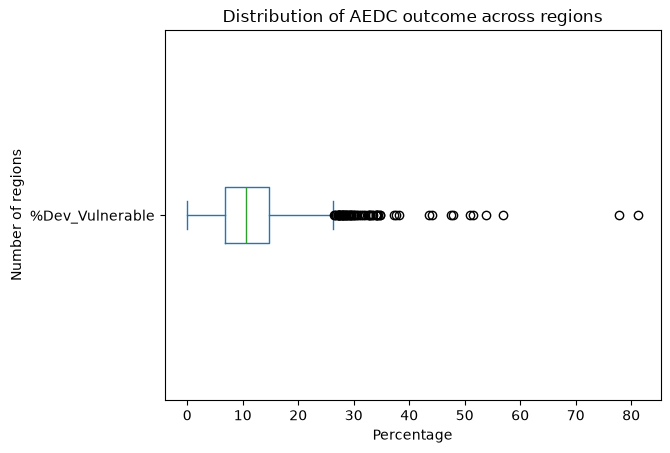

In [93]:
aedc_target["%Dev_Vulnerable"].plot.box(vert=False)
plt.xlabel("Percentage")
plt.ylabel("Number of regions")
plt.title("Distribution of AEDC outcome across regions")
plt.show()

Skewed target distribution, consider transformation

---

#### Load Australian Bureau of Statistics Data


In [94]:
ABS_census_features = pd.read_excel("data\\ABS_census_features.xlsx",
              sheet_name = "Features",
              dtype={"Code": str})

In [95]:
ABS_census_features.head()

,Code,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%
0,101021007,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637
1,101021008,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443
2,101021009,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738
3,101021010,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235
4,101021012,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228


In [96]:
ABS_census_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 2472 entries, 0 to 2471
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code                           2472 non-null   str    
 1   Median_tot_hhd_inc_weekly      2472 non-null   int64  
 2   Median_tot_prsnl_inc_weekly    2472 non-null   int64  
 3   Median_mortgage_repay_monthly  2472 non-null   int64  
 4   Median_rent_weekly             2472 non-null   int64  
 5   Average_num_psns_per_bedroom   2472 non-null   float64
 6   Average_household_size         2472 non-null   float64
 7   High_yr_schl_comp_Yr_12_eq_P   2472 non-null   int64  
 8   High_yr_schl_comp_Yr_10_eq_P   2472 non-null   int64  
 9   P_Tot_Emp_Tot                  2472 non-null   int64  
 10  P_Tot_Unemp_Tot                2472 non-null   int64  
 11  Tot_Indigenous_%               2472 non-null   float64
dtypes: float64(3), int64(8), str(1)
memory usage: 231.9 KB


---

#### 2. Data preprocessing / cleaning 

handle missing values, duplicates, noise, inconsistent formatting, outliers

#### Merge Target and features (join on SA2 code)

In [97]:
#AEDC contains fewer regions, "inner join" to keep records in both data sets
df = pd.merge(ABS_census_features, aedc_target, how="inner", on="Code")
df.head()

,Code,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%,Name,#Valid_Scores,#Dev_Vulnerable,%Dev_Vulnerable
0,101021007,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637,Braidwood,48,2.0,4.166667
1,101021008,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443,Karabar,98,17.0,17.346939
2,101021009,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738,Queanbeyan,125,17.0,13.600000
3,101021010,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235,Queanbeyan - East,62,7.0,11.290323
4,101021012,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228,Queanbeyan West - Jerrabomberra,195,15.0,7.692308


In [98]:
#Remove unnecessary target columns
df.drop(columns=["#Valid_Scores", "#Dev_Vulnerable"], inplace=True)


### 3.	Exploratory data analysis (EDA) 

In [99]:
#TODO: heatmap of features suspected correlation

---

### 4. Feature Engineering
The census data includes total counts, as well as counts stratafied by age, sex etc

For the purposes of this analysis we will construct features representing the socioeconomic demographics of the area (SA2s) such as employment rates, and housing affordability

In [100]:
#Housing affordability ratios (median weekly rent/ median total household income weekly) - higher ratio is a proxy for housing stress
df['rent_to_income_ratio'] = df['Median_rent_weekly'] / df['Median_tot_hhd_inc_weekly']
df['mortgage_to_income_ratio'] = df['Median_mortgage_repay_monthly'] / (df['Median_tot_hhd_inc_weekly'] * 4)  # Assuming 4 weeks in a month

In [ ]:
#Unemployment rate as total employed people divided by total people in the workforce (employed + unemployed)
df['Labour_force_total'] = df['P_Tot_Emp_Tot'] + df['P_Tot_Unemp_Tot']
df['Unemployment_rate'] = df['P_Tot_Unemp_Tot'] / df['Labour_force_total']

In [102]:
#Check new features for missing values 
df[['mortgage_to_income_ratio','rent_to_income_ratio','Unemployment_rate']].isna().sum()

mortgage_to_income_ratio    23
rent_to_income_ratio        22
Unemployment_rate           28
dtype: int64

In [103]:
#Review Areas without weekly income, unlikely to be residential 
df[df['Median_tot_hhd_inc_weekly'] == 0][['Code', 'Name', 'Median_tot_hhd_inc_weekly', 'Median_rent_weekly']]

,Code,Name,Median_tot_hhd_inc_weekly,Median_rent_weekly
672,205021080,Alps - East,0,0
675,205021083,Lake King,0,0
717,206041127,West Melbourne - Industrial,0,0
1271,308051537,South Trees,0,0
1351,310041301,New Chum,0,0
1655,404021098,Dry Creek - South,0,0
1835,506021120,Kewdale Commercial,0,0
1836,506021121,Perth Airport,0,0
1929,511031281,Kalgoorlie Airport,0,0
1932,511031284,Trafalgar (WA),0,0


Reviewing the above SA2s with $0 median weekly household income/rent, reveals the following:
- newly developing residential areas (Macnamara)
- Airports (Darwin Airport, Perth Airport, Kalgoorlie Airport)
- Commercial/Industrial (Kewdale Commercial, West Melbourne - Industrial)

As these areas are unlikely to contribute meaningful information about child welfare (non-residential SA2s, without families/dependents) we will remove these records from the data.

In [112]:
#Dropping areas without weekly income, assuming they are not important for child welfare (probably not a bunch of parentless children in the airports)
df = df[df['Median_tot_hhd_inc_weekly'] != 0]

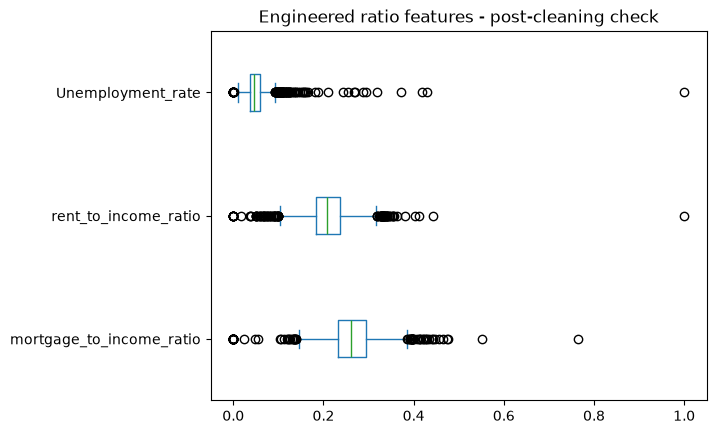

In [ ]:
#Visualise engineered features
df[['mortgage_to_income_ratio', 'rent_to_income_ratio', 'Unemployment_rate']].plot.box(vert=False)
plt.title("Engineered ratio features - post-cleaning check")
plt.show()

#### Scaling


---

### 5. Train/validation/test split 
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

In [106]:
X, y = df.drop(columns=["Code","Name", "%Dev_Vulnerable"]), df["%Dev_Vulnerable"]

In [107]:
X.head()

,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%,rent_to_income_ratio,mortgage_to_income_ratio,Labour_force_total,Unemployment_rate
0,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637,0.230931,0.303009,2081,0.032677
1,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443,0.175968,0.245098,4513,0.043873
2,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738,0.193776,0.249560,6517,0.041430
3,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235,0.172606,0.236637,3030,0.035644
4,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228,0.142668,0.190776,7568,0.022463


In [108]:
y.head()

0     4.166667
1    17.346939
2    13.600000
3    11.290323
4     7.692308
Name: %Dev_Vulnerable, dtype: float64

In [109]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf.get_n_splits()

5

In [110]:
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i+1}:")
    print(f"Train indices: {train_index}")
    print(f"Test indices: {test_index}")
    print()

Fold 1:
Train indices: [   0    1    2 ... 2183 2184 2186]
Test indices: [  13   23   29   44   49   51   56   59   63   65   67   69   70   71
   73   76   96   99  100  105  109  111  115  120  121  124  128  134
  135  162  168  173  178  179  184  185  188  196  198  205  210  211
  212  218  220  230  231  233  237  239  240  247  251  254  259  275
  281  282  289  290  296  297  298  299  303  306  307  308  316  321
  324  332  342  350  351  353  354  361  367  368  382  383  387  406
  408  409  410  414  416  420  422  426  427  430  432  433  438  445
  450  461  471  480  482  485  486  494  495  507  508  514  519  527
  528  529  530  535  538  543  544  548  552  554  555  561  571  582
  588  590  599  601  610  611  617  618  621  630  634  636  637  647
  650  651  668  670  678  693  694  695  715  736  746  755  759  764
  767  771  772  780  781  782  785  786  806  807  808  816  836  838
  839  849  855  861  862  865  873  888  889  892  893  905  907  914
  91

----

### 6. Training 

In [111]:
df.columns

Index(['Code', 'Median_tot_hhd_inc_weekly', 'Median_tot_prsnl_inc_weekly',
       'Median_mortgage_repay_monthly', 'Median_rent_weekly',
       'Average_num_psns_per_bedroom', 'Average_household_size',
       'High_yr_schl_comp_Yr_12_eq_P', 'High_yr_schl_comp_Yr_10_eq_P',
       'P_Tot_Emp_Tot', 'P_Tot_Unemp_Tot', 'Tot_Indigenous_%', 'Name',
       '%Dev_Vulnerable', 'rent_to_income_ratio', 'mortgage_to_income_ratio',
       'Labour_force_total', 'Unemployment_rate'],
      dtype='str')

----

### 7. Evaluation

---